2.1
a·b = 2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = -8
A×B = [[8,5],[1,-2]]，形状 (2,2)
||a||_F = √(2²+(-1)²+3²) = √14 ≈ 3.7417

2.2 编程题

In [1]:
import numpy as np

# 1. 3×4 标准正态随机矩阵
X = np.random.randn(3, 4)
print("X:\n", X)

# 2. 4×2 全1矩阵
Y = np.ones((4, 2))
print("\nY:\n", Y)

# 3. 矩阵乘法 Z = X @ Y
Z = X @ Y
print("\nZ:\n", Z)

# 4. 第一行第二列 & 第二行所有元素
print("\nZ[0,1] =", Z[0, 1])
print("Z第2行 =", Z[1])

# 5. Frobenius范数
print("\nZ的F范数 =", np.linalg.norm(Z))

X:
 [[-0.92199422  0.12753263 -0.98963554  0.78019056]
 [-1.28119248 -1.15049159 -1.20324479  0.56983478]
 [ 0.13297588  0.10362657 -0.15696375  0.08588926]]

Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z:
 [[-1.00390657 -1.00390657]
 [-3.06509407 -3.06509407]
 [ 0.16552796  0.16552796]]

Z[0,1] = -1.0039065650731587
Z第2行 = [-3.06509407 -3.06509407]

Z的F范数 = 4.567281364126616


3.1 贝叶斯理论题答案
患病率 P (A)=0.001，未患病 P (¬A)=0.999
灵敏度 P (+|A)=0.99，假阳性 P (+|¬A)=0.02
P(A|+) = (0.001×0.99) / (0.001×0.99 + 0.999×0.02)
= 0.00099 / 0.02097 ≈ 4.72%

3.2 中心极限定理模拟

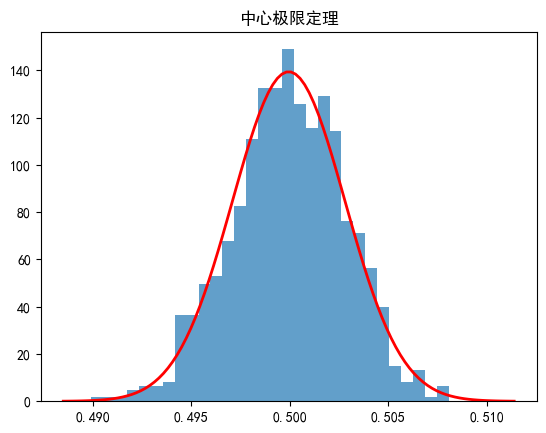

均值的方差 = 8.184733855304595e-06


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei'] 

# 1. 生成数据
n = 10000
m = 1000
means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

# 2. 画直方图 + 正态分布曲线
plt.hist(means, bins=30, density=True, alpha=0.7)
mu, std = np.mean(means), np.std(means)
x = np.linspace(mu - 4*std, mu + 4*std, 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r', linewidth=2)
plt.title("中心极限定理")
plt.show()

# 3. 实际方差
print("均值的方差 =", np.var(means))

4 导数、反向传播
4.1 理论题答案
z = (w1x1 + w2x2 − y)²
∂z/∂w1 = 2x1(w1x1 + w2x2 − y)
∂z/∂w2 = 2x2(w1x1 + w2x2 − y)
代入 x1=2,x2=1,y=3,w1=0.5,w2=1：
∂z/∂w1 = -4，∂z/∂w2 = -2

4.2 手动反向传播

In [3]:
import torch

# 前向
x = 2
w1 = 1.5
w2 = 0.5
a = x * w1
b = a + w2
L = b ** 2
print("前向损失 L =", L)

# 手动反向
dL_db = 2 * b
db_dw1 = x
db_dw2 = 1
dL_dw1 = dL_db * db_dw1
dL_dw2 = dL_db * db_dw2
print("手动梯度 dw1=", dL_dw1, " dw2=", dL_dw2)

# 自动微分验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)
b_t = x_t * w1_t + w2_t
L_t = b_t ** 2
L_t.backward()
print("torch梯度 dw1=", w1_t.grad.item(), " dw2=", w2_t.grad.item())

前向损失 L = 12.25
手动梯度 dw1= 14.0  dw2= 7.0
torch梯度 dw1= 14.0  dw2= 7.0


5 Softmax 回归（MNIST）

In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据
data = load_digits()
X = data.data / 16.0
y = data.target.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# one-hot
enc = OneHotEncoder(sparse=False)
y_train_one = enc.fit_transform(y_train)
y_test_one = enc.transform(y_test)

# 2. Softmax
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 3. 交叉熵
def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# 4. 训练
W = np.random.randn(64, 10) * 0.01
b = np.zeros(10)
lr = 0.1
epochs = 50
batch_size = 32

for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train_one[i:i+batch_size]
        z = X_batch @ W + b
        y_pred = softmax(z)
        # 梯度
        dz = (y_pred - y_batch) / len(X_batch)
        dW = X_batch.T @ dz
        db = np.sum(dz, axis=0)
        W -= lr * dW
        b -= lr * db

# 5. 测试准确率
y_pred_test = softmax(X_test @ W + b)
acc = np.mean(np.argmax(y_pred_test, axis=1) == y_test.flatten())
print("测试集准确率 =", acc)

测试集准确率 = 0.9444444444444444


d:\Anaconda\envs\torch310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


6 逻辑回归（二分类）

测试准确率 = 0.94


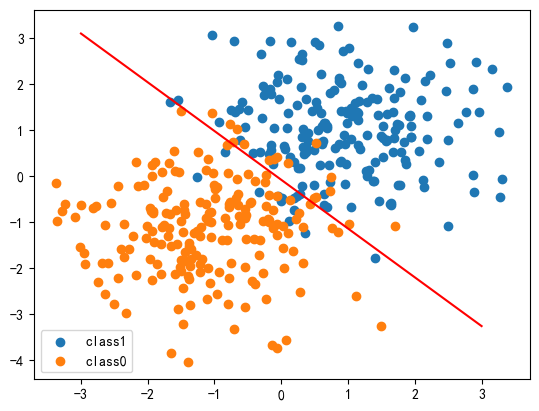

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成数据
np.random.seed(0)
n = 200
X1 = np.random.randn(n,2) + [1,1]
X2 = np.random.randn(n,2) + [-1,-1]
X = np.vstack([X1,X2])
y = np.hstack([np.ones(n), np.zeros(n)]).reshape(-1,1)

X_test = np.vstack([np.random.randn(50,2)+[1,1], np.random.randn(50,2)+[-1,-1]])
y_test = np.hstack([np.ones(50), np.zeros(50)])

# 2. Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 3. 训练
w = np.random.randn(2,1)
b = 0
lr = 0.1
iterations = 1000

for _ in range(iterations):
    z = X @ w + b
    y_pred = sigmoid(z)
    dz = y_pred - y
    dw = X.T @ dz / len(X)
    db = np.mean(dz)
    w -= lr * dw
    b -= lr * db

# 4. 准确率
y_pred_test = sigmoid(X_test @ w + b) > 0.5
acc = np.mean(y_pred_test.flatten() == y_test)
print("测试准确率 =", acc)

# 画决策边界
plt.scatter(X1[:,0], X1[:,1], label="class1")
plt.scatter(X2[:,0], X2[:,1], label="class0")
x1 = np.linspace(-3,3,100)
x2 = -(w[0]*x1 + b)/w[1]
plt.plot(x1,x2,'r')
plt.legend()
plt.show()